In [9]:
!pip install -q roboflow

In [10]:
from roboflow import Roboflow
rf = Roboflow(api_key="UzdNvPnNKiNrc6sILXsu")
project = rf.workspace("karass-workspace-uvtbw").project("object-detection-74uuj")
version = project.version(1)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [11]:
import os
for split in ["train", "valid", "test"]:
  path = f"/content/Object-Detection-1/{split}/images"
  if os.path.exists (path) :
      print(f" {split:>6s}: {len(os.listdir(path))} images")
  else:
      print(f" {split:>6s}: NOT FOUND")

  train: 332 images
  valid: 95 images
   test: 47 images


In [12]:
pip install ultralytics

In [13]:
import os
import cv2
import yaml
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import albumentations as A
from ultralytics import YOLO, RTDETR
import time

DATASET_DIR = Path("/content/Object-Detection-1")
AUG_DIR = Path("./project/augmented_dataset")
RESULTS_DIR = Path("./project/results")

with open(DATASET_DIR / "data.yaml", "r") as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config.get("names", [])
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

Classes (3): ['AirPods', 'Clay Pot', 'F50 Shoes -Orange-']


In [14]:
splits = {}
for split in ["train", "valid", "test"]:
    img_dir = DATASET_DIR / split / "images"
    if img_dir.exists():
        splits[split] = len(list(img_dir.glob("*")))
    else:
        splits[split] = 0

print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
for split, count in splits.items():
    print(f"  {split:>8s}: {count} images")
print(f"  {'TOTAL':>8s}: {sum(splits.values())} images")
print("=" * 40)

DATASET SUMMARY
     train: 332 images
     valid: 95 images
      test: 47 images
     TOTAL: 474 images


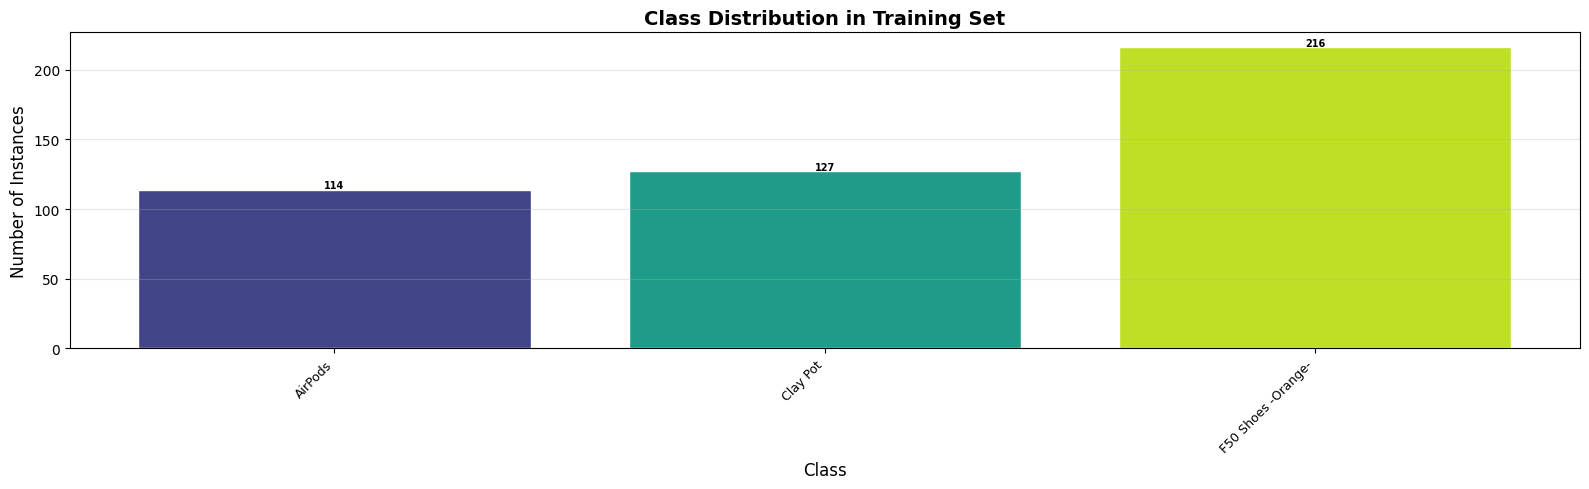


Total instances: 457
Min class: AirPods (114)
Max class: F50 Shoes -Orange- (216)


In [15]:
train_lbl_dir = DATASET_DIR / "train" / "labels"
class_counts = Counter()

for lbl_file in train_lbl_dir.glob("*.txt"):
    with open(lbl_file, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                class_counts[cls_id] += 1

# Sort by class ID
sorted_ids = sorted(class_counts.keys())
labels = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i) for i in sorted_ids]
counts = [class_counts[i] for i in sorted_ids]

fig, ax = plt.subplots(figsize=(16, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(labels)))
bars = ax.bar(labels, counts, color=colors, edgecolor="white")
ax.set_xlabel("Class", fontsize=12)
ax.set_ylabel("Number of Instances", fontsize=12)
ax.set_title("Class Distribution in Training Set", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha="center", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nTotal instances: {sum(counts)}")
print(f"Min class: {labels[np.argmin(counts)]} ({min(counts)})")
print(f"Max class: {labels[np.argmax(counts)]} ({max(counts)})")

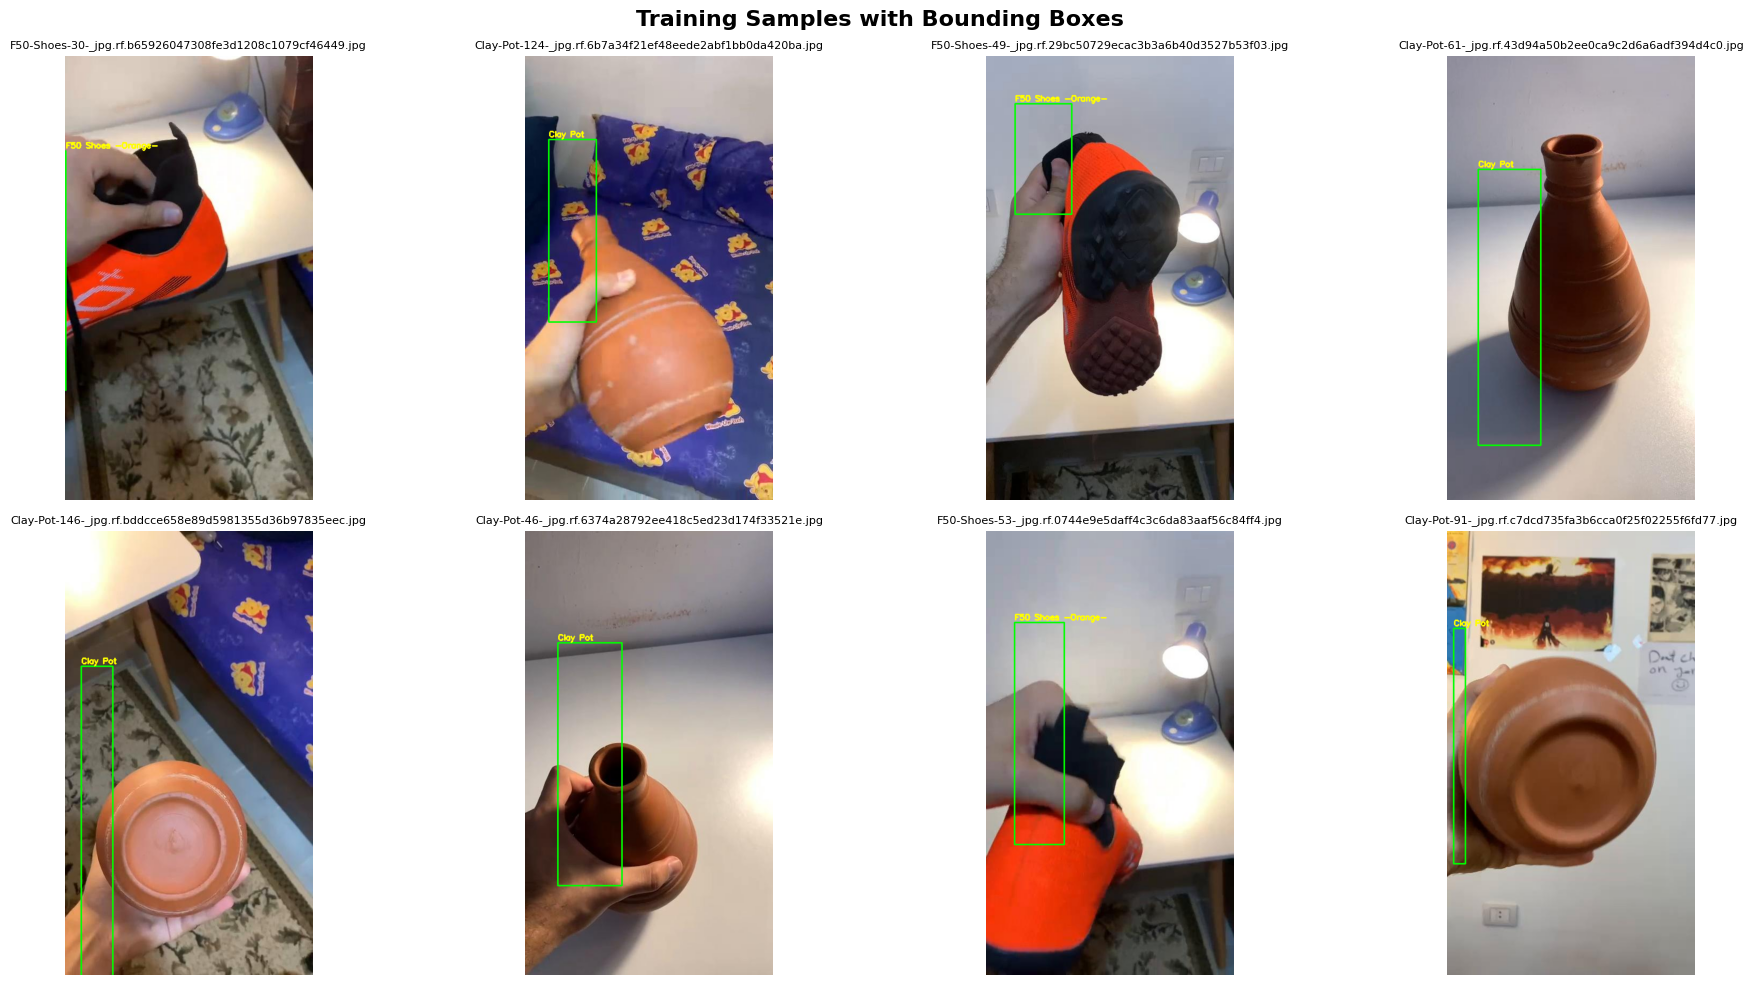

In [16]:
train_img_dir = DATASET_DIR / "train" / "images"
train_lbl_dir = DATASET_DIR / "train" / "labels"

sample_images = random.sample(list(train_img_dir.glob("*")), min(8, splits["train"]))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, img_path in enumerate(sample_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    if lbl_path.exists():
        with open(lbl_path, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1 = int((cx - bw/2) * w)
                    y1 = int((cy - bh/2) * h)
                    x2 = int((cx + bw/2) * w)
                    y2 = int((cy + bh/2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                    cv2.putText(img, label, (x1, y1 - 5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)

    axes[idx].imshow(img)
    axes[idx].set_title(img_path.name, fontsize=8)
    axes[idx].axis("off")

plt.suptitle("Training Samples with Bounding Boxes", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.CLAHE(clip_limit=3.0, p=0.3),
    A.Affine(scale=(0.85, 1.15), rotate=(-15, 15), p=0.4),
    A.ToGray(p=0.05),
], bbox_params=A.BboxParams(
    format="yolo",
    label_fields=["class_labels"],
    min_visibility=0.3,
    min_area=100
))

print("Augmentation pipeline ready.")

Augmentation pipeline ready.


Argument(s) 'var_limit' are not valid for transform GaussNoise


In [18]:

def read_yolo_labels(label_path):
    bboxes, class_labels = [], []
    if not Path(label_path).exists():
        return bboxes, class_labels
    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                bbox = [max(0.0, min(1.0, float(x))) for x in parts[1:5]]
                bboxes.append(bbox)
                class_labels.append(cls_id)
    return bboxes, class_labels


def write_yolo_labels(label_path, bboxes, class_labels):
    with open(label_path, "w") as f:
        for bbox, cls_id in zip(bboxes, class_labels):
            f.write(f"{cls_id} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

print("Helper functions defined.")

Helper functions defined.


In [19]:
AUGMENTATION_FACTOR = 3

src_img = DATASET_DIR / "train" / "images"
src_lbl = DATASET_DIR / "train" / "labels"
dst_img = AUG_DIR / "train" / "images"
dst_lbl = AUG_DIR / "train" / "labels"
dst_img.mkdir(parents=True, exist_ok=True)
dst_lbl.mkdir(parents=True, exist_ok=True)

image_paths = sorted(src_img.glob("*"))
total_generated = 0

for img_path in image_paths:
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    lbl_path = src_lbl / (img_path.stem + ".txt")
    bboxes, class_labels = read_yolo_labels(lbl_path)

    # Copy original
    shutil.copy2(img_path, dst_img / img_path.name)
    if lbl_path.exists():
        shutil.copy2(lbl_path, dst_lbl / (img_path.stem + ".txt"))

    # Generate augmented copies
    for i in range(AUGMENTATION_FACTOR):
        try:
            if len(bboxes) > 0:
                transformed = transform(image=img_rgb, bboxes=bboxes, class_labels=class_labels)
            else:
                continue

            aug_name = f"{img_path.stem}_aug{i}{img_path.suffix}"
            aug_img_bgr = cv2.cvtColor(transformed["image"], cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(dst_img / aug_name), aug_img_bgr)
            write_yolo_labels(dst_lbl / f"{img_path.stem}_aug{i}.txt",
                              transformed["bboxes"], transformed["class_labels"])
            total_generated += 1
        except:
            continue

# Copy valid and test as-is
for split in ["valid", "test"]:
    for sub in ["images", "labels"]:
        s = DATASET_DIR / split / sub
        d = AUG_DIR / split / sub
        if s.exists():
            shutil.copytree(s, d, dirs_exist_ok=True)

original = len(list(src_img.glob("*")))
final = len(list(dst_img.glob("*")))
print(f"Original: {original} | Augmented copies: {total_generated} | Total: {final}")

Original: 332 | Augmented copies: 645 | Total: 977


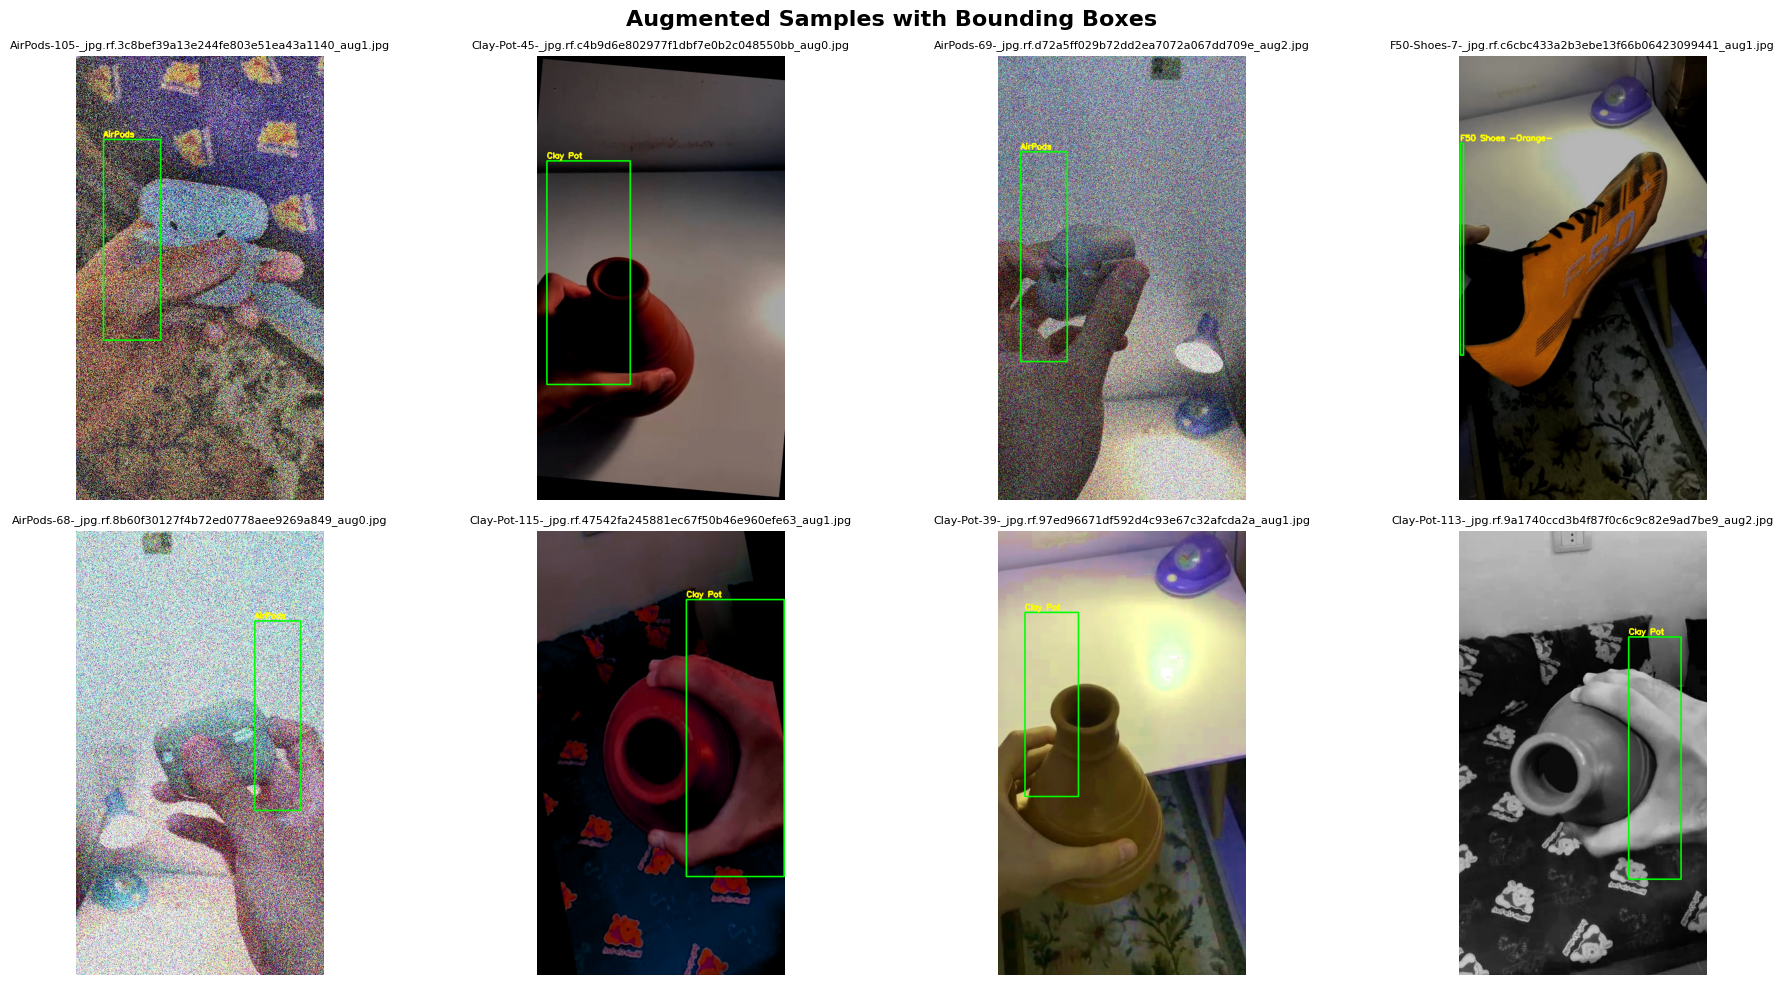

In [20]:
aug_samples = [p for p in sorted(dst_img.glob("*")) if "_aug" in p.stem]
random.shuffle(aug_samples)
aug_samples = aug_samples[:8]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, img_path in enumerate(aug_samples):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = dst_lbl / (img_path.stem + ".txt")
    if lbl_path.exists():
        with open(lbl_path, "r") as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    cls_id = int(float (parts[0]))
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1 = int((cx - bw/2) * w)
                    y1 = int((cy - bh/2) * h)
                    x2 = int((cx + bw/2) * w)
                    y2 = int((cy + bh/2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
                    cv2.putText(img, label, (x1, y1 - 5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)

    axes[idx].imshow(img)
    axes[idx].set_title(img_path.name, fontsize=8)
    axes[idx].axis("off")

plt.suptitle("Augmented Samples with Bounding Boxes", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [21]:
num_negatives = int(final * 0.10)

for i in range(num_negatives):
    choice = random.randint(0, 3)
    size = 640

    if choice == 0:
        img = np.full((size, size, 3), [random.randint(0,255) for _ in range(3)], dtype=np.uint8)
    elif choice == 1:
        img = np.random.randint(0, 256, (size, size, 3), dtype=np.uint8)
    elif choice == 2:
        grad = np.linspace(random.randint(0,128), random.randint(128,255), size)
        img = np.tile(grad.reshape(1, size, 1).astype(np.uint8), (size, 1, 3))
    else:
        s = random.randint(20, 80)
        img = np.zeros((size, size, 3), dtype=np.uint8)
        for y in range(0, size, s):
            for x in range(0, size, s):
                if ((y//s + x//s) % 2) == 0:
                    img[y:y+s, x:x+s] = random.randint(100, 255)

    if random.random() > 0.5:
        img = cv2.GaussianBlur(img, (5, 5), 0)

    cv2.imwrite(str(dst_img / f"negative_{i:04d}.jpg"), img)
    open(dst_lbl / f"negative_{i:04d}.txt", "w").close()

total_final = len(list(dst_img.glob("*")))
print(f"Negative samples added: {num_negatives}")
print(f"Final dataset size: {total_final} images")

Negative samples added: 97
Final dataset size: 1074 images


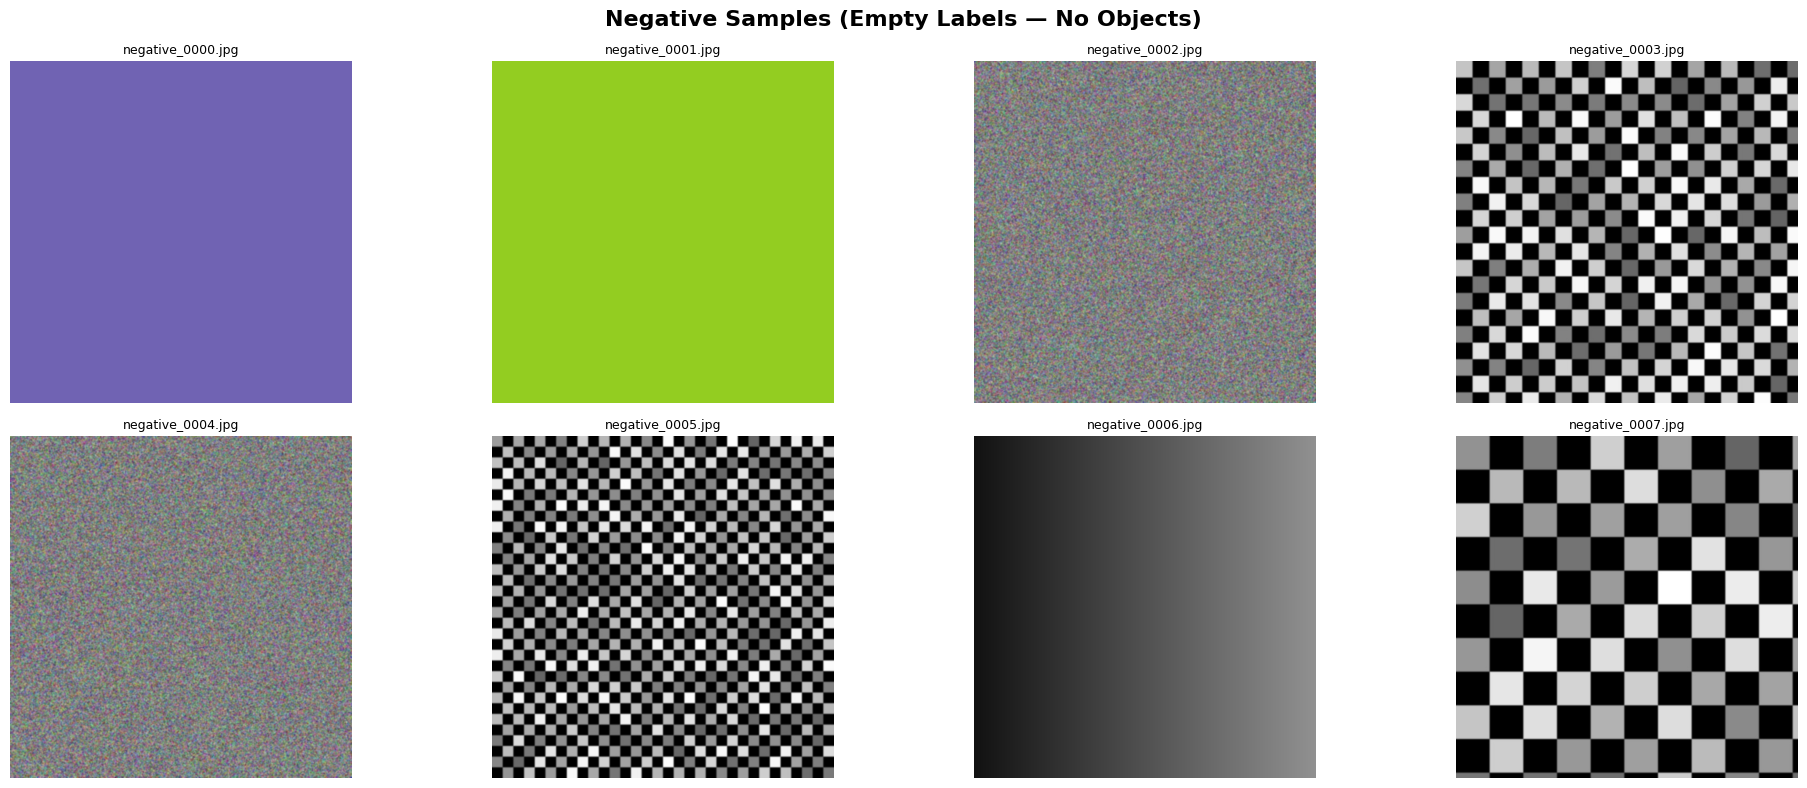

Total negative samples: 97


In [22]:
neg_images = sorted(dst_img.glob("negative_*"))[:8]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for idx, img_path in enumerate(neg_images):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img)
    axes[idx].set_title(img_path.name, fontsize=9)
    axes[idx].axis("off")

plt.suptitle("Negative Samples (Empty Labels — No Objects)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Total negative samples: {len(list(dst_img.glob('negative_*')))}")

In [23]:
aug_yaml = AUG_DIR / "data.yaml"

data = {
    "path": str(AUG_DIR.resolve()),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images" if (AUG_DIR / "test" / "images").exists() else "valid/images",
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES,
}

with open(aug_yaml, "w") as f:
    yaml.dump(data, f, default_flow_style=False)

print("data.yaml created:")
with open(aug_yaml) as f:
    print(f.read())

data.yaml created:
names:
- AirPods
- Clay Pot
- F50 Shoes -Orange-
nc: 3
path: /content/project/augmented_dataset
test: test/images
train: train/images
val: valid/images



In [25]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

yolo_model = YOLO("yolo26n.pt")

yolo_model.train(
    data=str(aug_yaml),
    epochs=70,
    imgsz=640,
    batch=16,
    patience=10,
    name="yolo_run",
    project=str(RESULTS_DIR),
    exist_ok=True,
)

print("YOLOv26 training complete!")

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=project/augmented_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_run, nbs=64, nms=False

In [26]:
from ultralytics import YOLO

# 1. Load the model using the path
yolo_best = YOLO("/content/runs/detect/project/results/yolo_run/weights/best.pt")

# 2. Evaluate it
yolo_metrics = yolo_best.val(data=str(aug_yaml), imgsz=640)

yolo_p = yolo_metrics.box.mp
yolo_r = yolo_metrics.box.mr
yolo_map50 = yolo_metrics.box.map50
yolo_map = yolo_metrics.box.map

print("=" * 50)
print("YOLO RESULTS")
print("=" * 50)
print(f"  Precision    : {yolo_p:.4f}")
print(f"  Recall       : {yolo_r:.4f}")
print(f"  mAP@0.50     : {yolo_map50:.4f}")
print(f"  mAP@0.50:0.95: {yolo_map:.4f}")

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1295.5±414.6 MB/s, size: 24.2 KB)
val: Scanning /content/project/augmented_dataset/valid/labels.cache... 95 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 39.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.0it/s 2.0s
                   all         95        131      0.973      0.782      0.854      0.804
               AirPods         32         34      0.946      0.882      0.967      0.926
              Clay Pot         28         29          1      0.915      0.963      0.955
    F50 Shoes -Orange-         35         68      0.974       0.55      0.632      0.532
Speed: 3.0ms preprocess, 7.0ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/v

In [27]:
rtdetr_model = RTDETR("rtdetr-l.pt")

rtdetr_model.train(
data=str(aug_yaml),
epochs=30,
imgsz=640,
batch=16,
patience=10,
name="rtdetr_run",
project=str(RESULTS_DIR),
exist_ok=True,
)

print("RT-DETR training complete!")

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=project/augmented_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=rtdetr_run, nbs=64, nms=Fa

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       1/30      12.5G     0.9731      10.51     0.8468          4        640: 100% ━━━━━━━━━━━━ 68/68 1.3s/it 1:31
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.2s/it 6.6s
                   all         95        131      0.667       0.58      0.677      0.451

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


       2/30      12.6G      0.781     0.9278     0.6595          5        640: 100% ━━━━━━━━━━━━ 68/68 1.2s/it 1:19
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.0s
                   all         95        131      0.762      0.658      0.689      0.535

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

      28/30      12.7G     0.3086     0.4881     0.2416          2        640: 100% ━━━━━━━━━━━━ 68/68 1.1s/it 1:17
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.0s
                   all         95        131      0.877       0.82      0.829        0.8

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      29/30      12.7G     0.3072     0.4875     0.2362          2        640: 100% ━━━━━━━━━━━━ 68/68 1.1s/it 1:17
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.4it/s 2.1s
                   all         95        131      0.978      0.807      0.844      0.811

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      30/30      12.7G     0.2932     0.4695     0.2331          2        640: 100% ━━━━━━━━━━━━ 68/68 1.1s/it 1:18
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 2.0s
                   all         95        131      0.989      0.838      0.851      0.816

30 epochs completed in 0.762 hours.
Optimizer stripped from /content/runs/detect/project/results/rtdetr_run/weights/last.pt, 66.2MB
Optimizer stripped from /content/runs/detect/project/results/rtdetr_run/weights/best.pt, 66.2MB

Validating /content/runs/detect/project/results/rtdetr_run/weights/best.pt...
Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 315 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.8s
                   all         95        131      0.989      0.838      0